In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='Diagnosis')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [4]:
# - Evaluate the model using accuracy, confusion matrix, precision, recall, and F1-score.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1_score: {f1}")

Accuracy: 0.956140350877193
Precision: 0.9459459459459459
Recall: 0.9859154929577465
F1_score: 0.9655172413793104


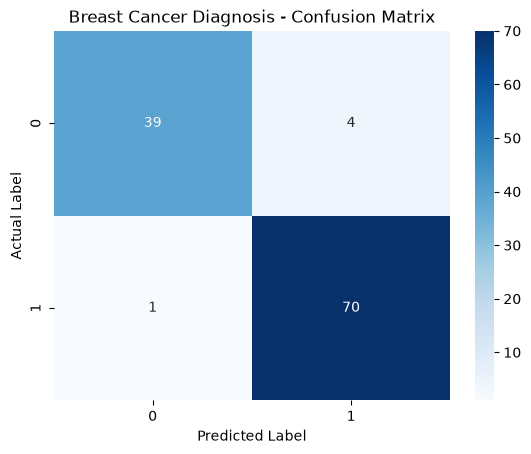

In [6]:
# - Visualize the confusion matrix using Seaborn's heatmap.
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Breast Cancer Diagnosis - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [7]:
sample_data = X_test.sample(5, random_state=12)
actual_labels = y_test.loc[sample_data.index]

sample_predictions = model.predict(sample_data)

print("Patient ID | Actual Diagnosis | Predicted        | Correct?")
print("-" * 60)

for index, actual, predicted in zip(sample_data.index, actual_labels, sample_predictions):
    # 0 - Malignant, 1 - Benign
    actual_text = "Benign" if actual == 1 else "Malignant"
    pred_text = "Benign" if predicted == 1 else "Malignant"
    status = "✅ Yes" if actual == predicted else "❌ No"
    
    print(f"{index:<10} | {actual_text:<16} | {pred_text:<16} | {status}")

Patient ID | Actual Diagnosis | Predicted        | Correct?
------------------------------------------------------------
118        | Malignant        | Malignant        | ✅ Yes
331        | Benign           | Benign           | ✅ Yes
556        | Benign           | Benign           | ✅ Yes
11         | Malignant        | Malignant        | ✅ Yes
167        | Malignant        | Malignant        | ✅ Yes


In [8]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("--- Baseline Model Performance ---")

baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {baseline_accuracy:.4f}\n")

print("--- Cross-Validation Performance ---")
cv_model = LogisticRegression(max_iter=5000)

cv_scores = cross_val_score(cv_model, X, y, cv=5, scoring='accuracy')

print(f"Accuracy for each of the 5 folds: {cv_scores}")
print(f"Average Cross-Validation Accuracy: {np.mean(cv_scores):.4f}")

--- Baseline Model Performance ---
Baseline Accuracy: 0.9561

--- Cross-Validation Performance ---
Accuracy for each of the 5 folds: [0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Average Cross-Validation Accuracy: 0.9508
